## What You’ll learn
How to apply various statistical functions using SciPy
Understanding probability distributions and hypothesis testing
Analyzing data with regression, ANOVA, and correlation methods

## What you will create
You will create a series of Python scripts that perform different statistical analyses, including data exploration, hypothesis testing, linear regression, ANOVA, and more.

## Exercise 1: Basic Usage of SciPy
Task: Import the SciPy library and explore its version.



In [1]:
import scipy
print("SciPy version:", scipy.__version__)
print("\nModules disponibles dans SciPy:")
print(dir(scipy))

SciPy version: 1.17.1

Modules disponibles dans SciPy:
['LowLevelCallable', '__version__', 'cluster', 'constants', 'datasets', 'differentiate', 'fft', 'fftpack', 'integrate', 'interpolate', 'io', 'linalg', 'ndimage', 'odr', 'optimize', 'show_config', 'signal', 'sparse', 'spatial', 'special', 'stats', 'test']


## Exercise 2: Descriptive Statistics
Task: Given a sample dataset, calculate the mean, median, variance, and standard deviation using SciPy.
Sample Dataset:
data = [12, 15, 13, 12, 18, 20, 22, 21]

In [2]:
import numpy as np
from scipy import stats
data = [12, 15, 13, 12, 18, 20, 22, 21]
mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data)
std_dev = np.std(data)
variance = np.var(data)
print(f"Data        : {data}")
print(f"Mean        : {mean}")
print(f"Median      : {median}")
print(f"Variance    : {variance}")
print(f"Std Dev     : {std_dev}")
print(f"Mode        : {mode.mode} (appears {mode.count} times)")

Data        : [12, 15, 13, 12, 18, 20, 22, 21]
Mean        : 16.625
Median      : 16.5
Variance    : 14.984375
Std Dev     : 3.8709656418005056
Mode        : 12 (appears 2 times)


## Exercise 3: Understanding Distributions
Task: Generate a normal distribution using SciPy with a mean of 50 and a standard deviation of 10. Plot this distribution.
Code Example:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# complete your code here

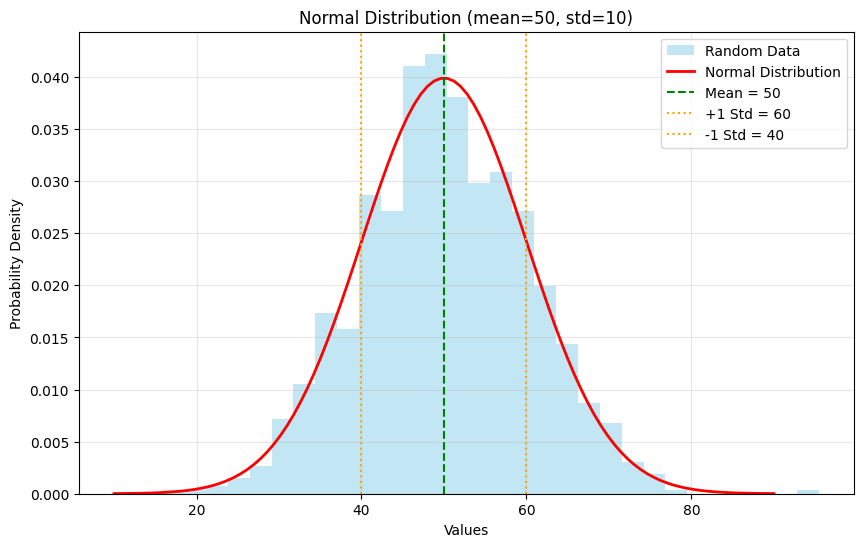

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
mean = 50
std = 10
x = np.linspace(mean - 4*std, mean + 4*std, 100)
y = norm.pdf(x, mean, std)
data = norm.rvs(loc=mean, scale=std, size=1000)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.5, color="skyblue", label="Random Data")
plt.plot(x, y, color="red", linewidth=2, label="Normal Distribution")
plt.axvline(mean, color="green", linestyle="--", linewidth=1.5, label=f"Mean = {mean}")
plt.axvline(mean + std, color="orange", linestyle=":", linewidth=1.5, label=f"+1 Std = {mean+std}")
plt.axvline(mean - std, color="orange", linestyle=":", linewidth=1.5, label=f"-1 Std = {mean-std}")
plt.title("Normal Distribution (mean=50, std=10)")
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 4: T-Test Application
Task: Perform a T-test on two sets of randomly generated data.
Code Example:
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

# complete your code here

In [4]:
import numpy as np
from scipy import stats
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)
t_statistic, p_value = stats.ttest_ind(data1, data2)
print(f"T-Statistic : {t_statistic:.4f}")
print(f"P-Value     : {p_value:.4f}")
if p_value < 0.05:
    print("The two groups ARE significantly different (p < 0.05)")
else:
    print("The two groups are NOT significantly different (p >= 0.05)")

T-Statistic : -7.3191
P-Value     : 0.0000
The two groups ARE significantly different (p < 0.05)


## Exercise 5: Linear Regression Analysis
Objective: Apply linear regression to a dataset and interpret the results.

Task: Given a dataset of housing prices (house_prices) and their corresponding sizes (house_sizes), use linear regression to predict the price of a house given its size.
Dataset:
house_sizes: [50, 70, 80, 100, 120] (in square meters)
house_prices: [150,000, 200,000, 210,000, 250,000, 280,000] (in currency units)
Questions:
What is the slope and intercept of the regression line?
Predict the price of a house that is 90 square meters.
Interpret the meaning of the slope in the context of housing prices.

Slope       : 1828.77
Intercept   : 64383.56
R²          : 0.9884
P-Value     : 0.0005
Std Error   : 114.27
Predicted price for 90m² : 228,972.60

--- Interpretation ---
For every 1m² increase in size,
the price increases by 1828.77 currency units.


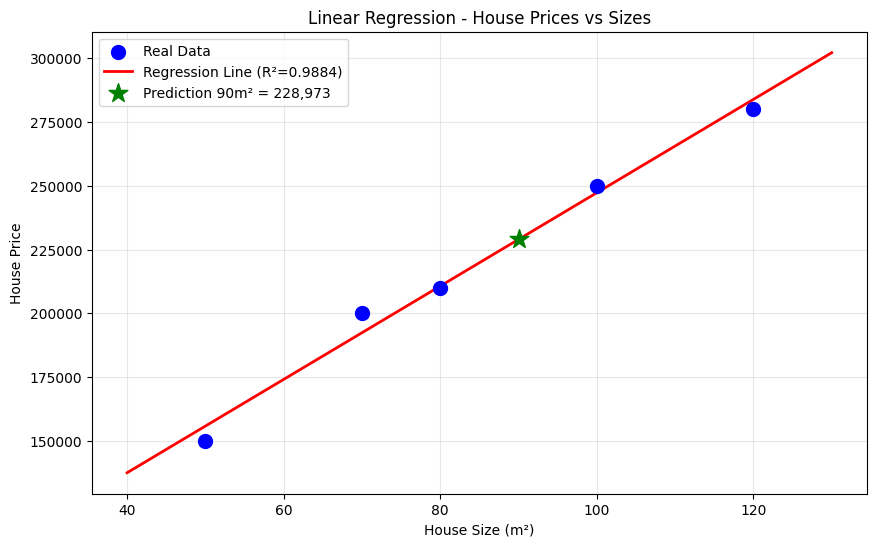

In [6]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
house_sizes  = [50, 70, 80, 100, 120]
house_prices = [150000, 200000, 210000, 250000, 280000]
slope, intercept, r_value, p_value, std_err = stats.linregress(house_sizes, house_prices)

print(f"Slope       : {slope:.2f}")
print(f"Intercept   : {intercept:.2f}")
print(f"R²          : {r_value**2:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"Std Error   : {std_err:.2f}")
size_to_predict = 90
predicted_price = slope * size_to_predict + intercept

print(f"Predicted price for {size_to_predict}m² : {predicted_price:,.2f}")
print(f"\n--- Interpretation ---")
print(f"For every 1m² increase in size,")
print(f"the price increases by {slope:.2f} currency units.")
x_line = np.linspace(40, 130, 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 6))
plt.scatter(house_sizes, house_prices, color="blue", s=100, zorder=5, label="Real Data")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"Regression Line (R²={r_value**2:.4f})")
plt.scatter(size_to_predict, predicted_price, color="green", s=200, zorder=5,
            marker="*", label=f"Prediction 90m² = {predicted_price:,.0f}")

plt.title("Linear Regression - House Prices vs Sizes")
plt.xlabel("House Size (m²)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 6: Understanding ANOVA
Objective: Test understanding of ANOVA and its application.

Task: Three different fertilizers are applied to three separate groups of plants to test their effectiveness. The growth in centimeters is recorded.
Dataset:
fertilizer_1: [5, 6, 7, 6, 5]
fertilizer_2: [7, 8, 7, 9, 8]
fertilizer_3: [4, 5, 4, 3, 4]
Questions:
Perform an ANOVA test on the given data. What are the F-value and P-value?
Based on the P-value, do the fertilizers have significantly different effects on plant growth?
Explain what would happen if the P-value were greater than 0.05.


Slope       : 1828.77
Intercept   : 64383.56
R²          : 0.9884
P-Value     : 0.0005
Std Error   : 114.27
Predicted price for 90m² : 228,972.60
For every 1m² increase, price increases by 1828.77


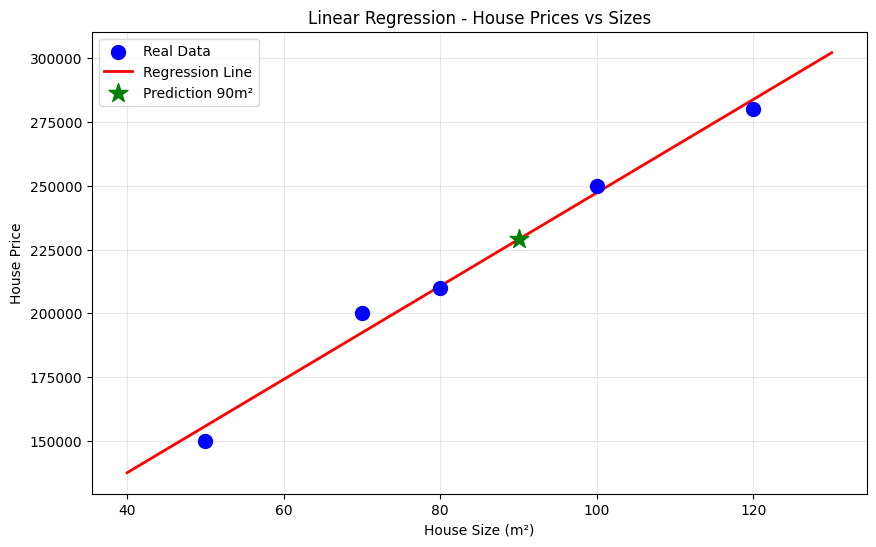

In [7]:
house_sizes  = [50, 70, 80, 100, 120]
house_prices = [150000, 200000, 210000, 250000, 280000]
slope, intercept, r_value, p_value, std_err = stats.linregress(house_sizes, house_prices)

print(f"Slope       : {slope:.2f}")
print(f"Intercept   : {intercept:.2f}")
print(f"R²          : {r_value**2:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"Std Error   : {std_err:.2f}")
size_to_predict = 90
predicted_price = slope * size_to_predict + intercept

print(f"Predicted price for {size_to_predict}m² : {predicted_price:,.2f}")
print(f"For every 1m² increase, price increases by {slope:.2f}")
x_line = np.linspace(40, 130, 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 6))
plt.scatter(house_sizes, house_prices, color="blue", s=100, zorder=5, label="Real Data")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"Regression Line")
plt.scatter(size_to_predict, predicted_price, color="green", s=200, zorder=5,
            marker="*", label=f"Prediction 90m²")
plt.title("Linear Regression - House Prices vs Sizes")
plt.xlabel("House Size (m²)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 7: Probability Distributions (Optional)
Work with a binomial distribution: calculate probabilities for different numbers of successes.
Example: Calculating the probability of getting exactly 5 heads in 10 coin flips.

Parameters  : n=10 flips, p=0.5 probability

P(exactly 5 heads)  : 0.2461  (24.61%)
P(at most 5 heads)  : 0.6230  (62.30%)
P(at least 5 heads) : 0.6230  (62.30%)
 0 heads : 0.0010 (0.10%) 
 1 heads : 0.0098 (0.98%) 
 2 heads : 0.0439 (4.39%) 
 3 heads : 0.1172 (11.72%) 
 4 heads : 0.2051 (20.51%) 
 5 heads : 0.2461 (24.61%) 
 6 heads : 0.2051 (20.51%) 
 7 heads : 0.1172 (11.72%) 
 8 heads : 0.0439 (4.39%) 
 9 heads : 0.0098 (0.98%) 
10 heads : 0.0010 (0.10%) 


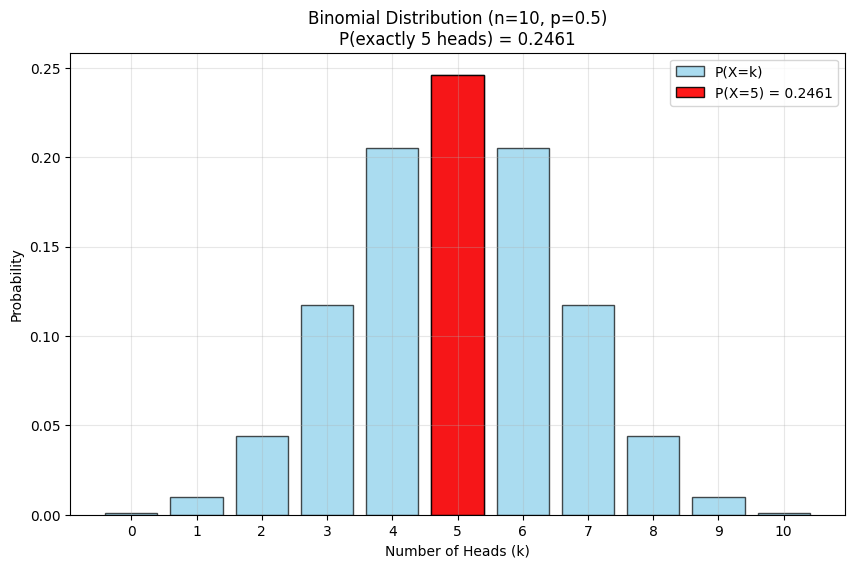

In [8]:
n = 10      
p = 0.5     
k = 5
prob_exact = stats.binom.pmf(k, n, p)
prob_cumulative = stats.binom.cdf(k, n, p)
prob_at_least = 1 - stats.binom.cdf(k - 1, n, p)
print(f"Parameters  : n={n} flips, p={p} probability")
print(f"\nP(exactly 5 heads)  : {prob_exact:.4f}  ({prob_exact*100:.2f}%)")
print(f"P(at most 5 heads)  : {prob_cumulative:.4f}  ({prob_cumulative*100:.2f}%)")
print(f"P(at least 5 heads) : {prob_at_least:.4f}  ({prob_at_least*100:.2f}%)")
for i in range(n + 1):
    prob = stats.binom.pmf(i, n, p)
    bar = "" * int(prob * 100)
    print(f"{i:2d} heads : {prob:.4f} ({prob*100:.2f}%) {bar}")
x = np.arange(0, n + 1)
probabilities = stats.binom.pmf(x, n, p)
plt.figure(figsize=(10, 6))
plt.bar(x, probabilities, color="skyblue", edgecolor="black", alpha=0.7, label="P(X=k)")
plt.bar(k, prob_exact, color="red", edgecolor="black", alpha=0.9, label=f"P(X=5) = {prob_exact:.4f}")

plt.title(f"Binomial Distribution (n={n}, p={p})\nP(exactly 5 heads) = {prob_exact:.4f}")
plt.xlabel("Number of Heads (k)")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## Exercise 8: Correlation Coefficients (Optional)
Calculate the Pearson and Spearman correlation coefficients between two variables in a dataset.
Example in code: data = pd.DataFrame({'age': [23, 25, 30, 35, 40], 'income': [35000, 40000, 50000, 60000, 70000]})


--- Dataset ---
   age  income
0   23   35000
1   25   40000
2   30   50000
3   35   60000
4   40   70000

--- Pearson Correlation ---
Coefficient : 0.9997
P-Value     : 0.0000

--- Spearman Correlation ---
Coefficient : 1.0000
P-Value     : 0.0000
Pearson    : 0.9997 → Very Strong Positive correlation | ✅ Significant
Spearman   : 1.0000 → Very Strong Positive correlation | ✅ Significant


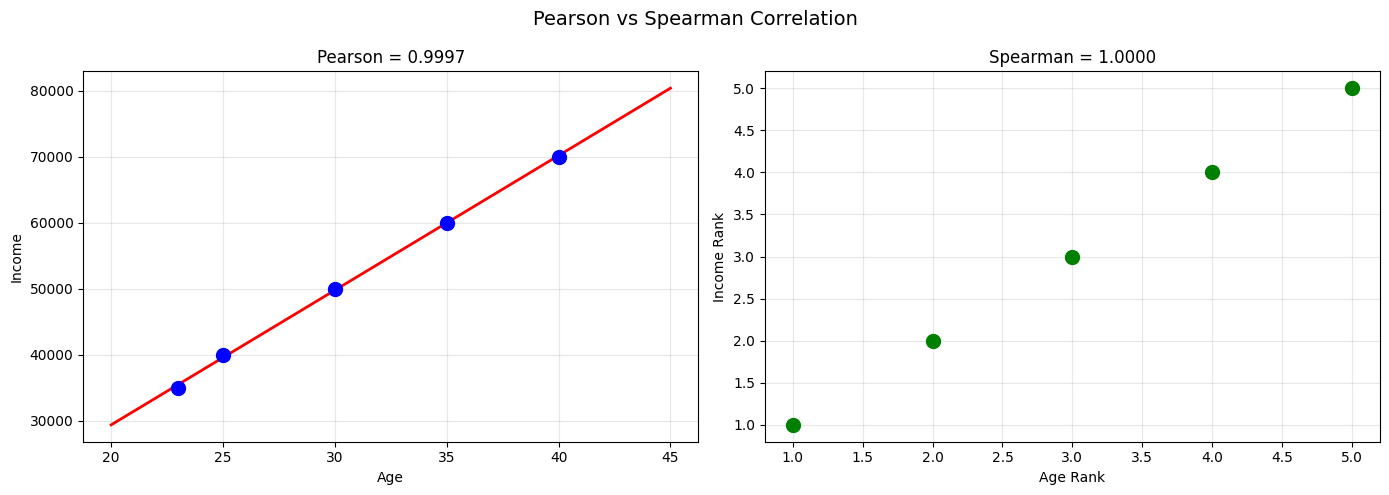

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'age':    [23, 25, 30, 35, 40],
    'income': [35000, 40000, 50000, 60000, 70000]
})

print("--- Dataset ---")
print(data)

pearson_corr = np.corrcoef(data['age'], data['income'])[0, 1]
pearson_p = stats.pearsonr(list(data['age']), list(data['income']))[1]

print("\n--- Pearson Correlation ---")
print(f"Coefficient : {pearson_corr:.4f}")
print(f"P-Value     : {pearson_p:.4f}")

spearman_corr, spearman_p = stats.spearmanr(list(data['age']), list(data['income']))
print("\n--- Spearman Correlation ---")
print(f"Coefficient : {spearman_corr:.4f}")
print(f"P-Value     : {spearman_p:.4f}")

for name, corr, p in [("Pearson", pearson_corr, pearson_p),
                    ("Spearman", spearman_corr, spearman_p)]:
    if abs(corr) >= 0.9:
        strength = "Very Strong"
    elif abs(corr) >= 0.7:
        strength = "Strong"
    elif abs(corr) >= 0.5:
        strength = "Moderate"
    else:
        strength = "Weak"

    direction = "Positive" if corr > 0 else "Negative"
    significant = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    print(f"{name:10} : {corr:.4f} → {strength} {direction} correlation | {significant}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(data['age'], data['income'], color="blue", s=100, zorder=5)
slope, intercept, _, _, _ = stats.linregress(data['age'], data['income'])
x_line = np.linspace(20, 45, 100)
axes[0].plot(x_line, slope * x_line + intercept, color="red", linewidth=2)
axes[0].set_title(f"Pearson = {pearson_corr:.4f}")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Income")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data['age'].rank(), data['income'].rank(), color="green", s=100, zorder=5)
axes[1].set_title(f"Spearman = {spearman_corr:.4f}")
axes[1].set_xlabel("Age Rank")
axes[1].set_ylabel("Income Rank")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Pearson vs Spearman Correlation", fontsize=14)
plt.tight_layout()
plt.show()